In [1]:

# Step 3: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/car data.csv')

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Dataset shape
print("Dataset shape:", df.shape)

# Column names
print("Columns:")
print(df.columns.tolist())

# Dataset information
df.info()

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Dataset shape: (301, 9)
Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype

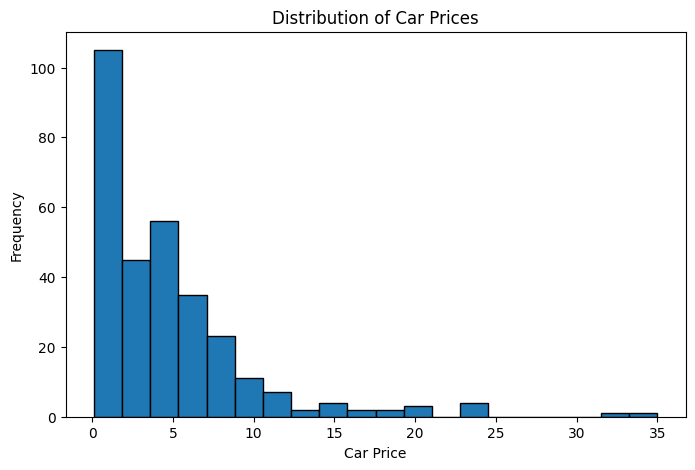

In [3]:
# Distribution of car prices

# Change 'price' if your target column has a different name
price_col = 'Selling_Price'

plt.figure(figsize=(8, 5))
plt.hist(df[price_col], bins=20, edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Car Price')
plt.ylabel('Frequency')
plt.show()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


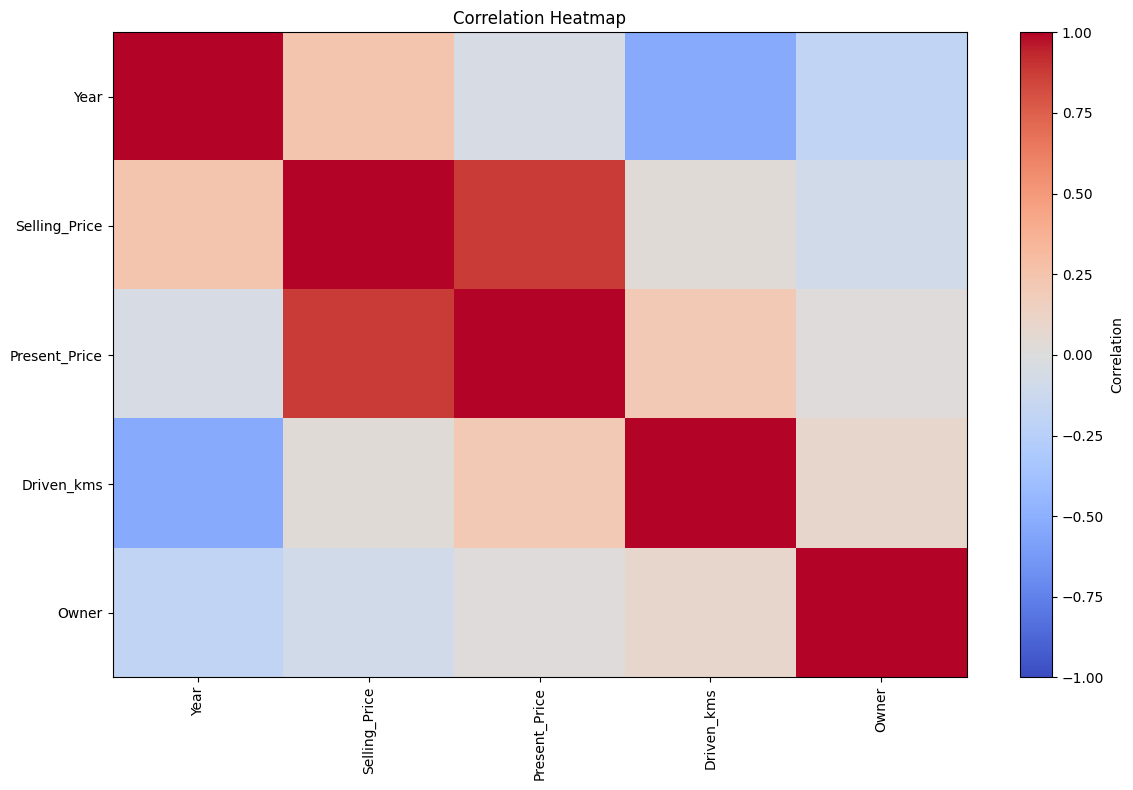

In [4]:

# Summary statistics
display(df.describe())

# Correlation between numerical features
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns,
           rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [5]:

# Step 5: Data preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Find the target price column
target_options = ['price', 'selling_price', 'car_price']

target_col = next(
    (col for col in df.columns
     if col.lower().replace(' ', '').replace('_', '') in
     [t.replace('_', '') for t in target_options]),
    None
)

if target_col is None:
    raise ValueError(
        "Price column not found. Check your dataset's column names."
    )

# Remove unnecessary unnamed columns
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed')].copy()

# Convert target to numeric
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col]).copy()

# Feature engineering: extract brand if car name is available
name_col = next(
    (col for col in df.columns
     if col.lower().replace('_', '').replace(' ', '') == 'carname'),
    None
)

if name_col:
    df['brand'] = (
        df[name_col].astype(str).str.strip().str.split().str[0]
    )
    df = df.drop(columns=[name_col])

# Remove ID columns if present
id_cols = [
    col for col in df.columns
    if col.lower().replace('_', '').replace(' ', '')
    in ['carid', 'id']
]
df = df.drop(columns=id_cols)

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify categorical and numerical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Training samples: 240
Testing samples: 61
Numerical features: ['Year', 'Present_Price', 'Driven_kms', 'Owner']
Categorical features: ['Fuel_Type', 'Selling_type', 'Transmission', 'brand']


In [6]:

# Step 6: Train regression models

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )
}

trained_models = {}
results = {}

# Train and evaluate
for name, regressor in models.items():

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    trained_models[name] = model
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

    print(f"\n{name}")
    print("MAE:", round(mae, 2))
    print("MSE:", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 Score:", round(r2, 4))


Linear Regression
MAE: 1.06
MSE: 2.66
RMSE: 1.63
R2 Score: 0.8843

Random Forest
MAE: 0.6
MSE: 0.83
RMSE: 0.91
R2 Score: 0.9641


Model Performance Comparison:


,MAE,MSE,RMSE,R2 Score
Linear Regression,1.063933,2.664578,1.632354,0.884328
Random Forest,0.600786,0.826985,0.909387,0.964100


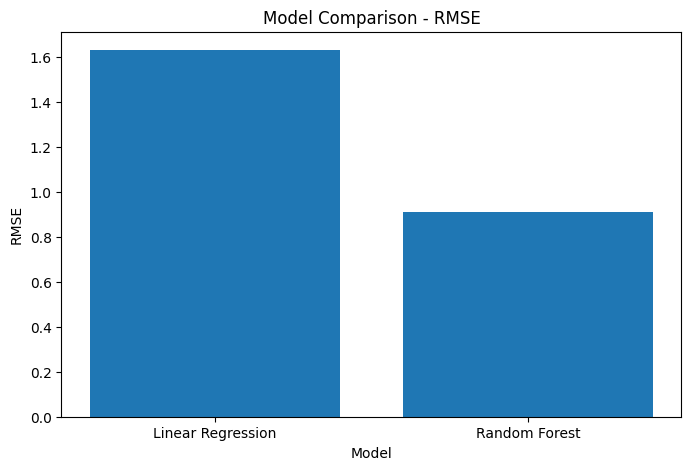

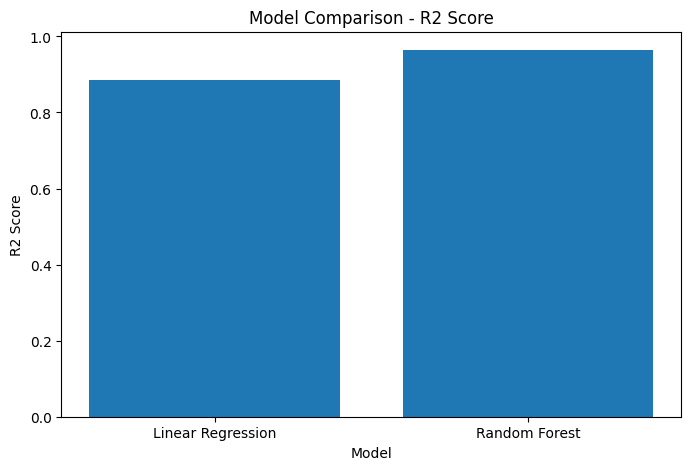

In [7]:

# Step 7: Compare models

results_df = pd.DataFrame(results).T

print("Model Performance Comparison:")
display(results_df)

# Visualize RMSE
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df['RMSE'])
plt.title('Model Comparison - RMSE')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.show()

# Visualize R2 Score
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df['R2 Score'])
plt.title('Model Comparison - R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.show()

In [8]:

# Step 8: Select best model based on test RMSE

best_model_name = results_df['RMSE'].idxmin()
best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)
print("Test RMSE:", results_df.loc[best_model_name, 'RMSE'])

# Save model
import joblib

joblib.dump(
    best_model,
    'car_price_prediction_model.pkl'
)

print("Model saved successfully!")

Selected model: Random Forest
Test RMSE: 0.9093871451194802
Model saved successfully!


In [9]:

# Step 9: Test prediction

# Take one sample from test data
sample = X_test.iloc[[0]]

# Predict car price
predicted_price = best_model.predict(sample)[0]

# Actual price
actual_price = y_test.iloc[0]

print("Predicted Car Price:", round(predicted_price, 2))
print("Actual Car Price:", round(actual_price, 2))

Predicted Car Price: 0.44
Actual Car Price: 0.35


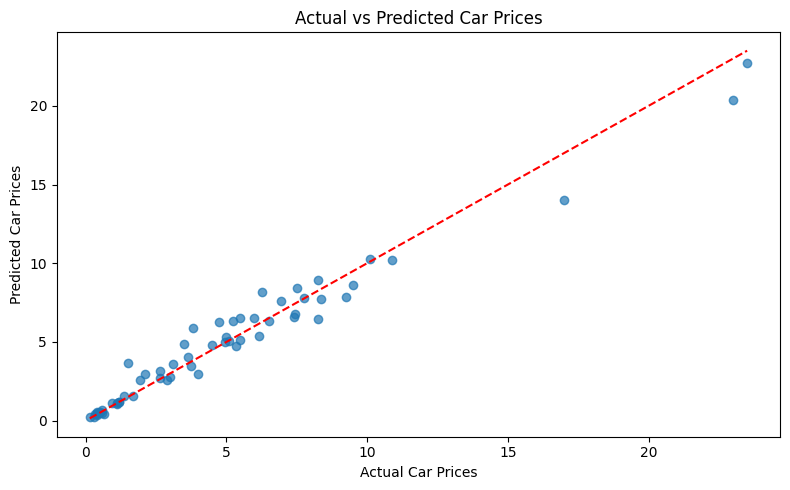

In [10]:

# Step 10: Actual vs Predicted prices

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Car Prices')
plt.ylabel('Predicted Car Prices')
plt.title('Actual vs Predicted Car Prices')

# Reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price],
         [min_price, max_price], 'r--')

plt.tight_layout()
plt.show()

In [11]:

# Download trained model

from google.colab import files

files.download('car_price_prediction_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>